# 04 — Label Generation

**BBL514E Pattern Recognition — Term Project (MVP)**

Üç stage için etiketler:
1. **Stage 1 (Trend)** — SMA crossover + 3-day persistence → Uptrend / Downtrend / Sideways
2. **Stage 2 (Macro Regime)** — GMM soft posterior (OOF on train, predict on test) → 3 cluster (Risk-On / Neutral / Risk-Off semantik atama)
3. **Stage 3 (Signal)** — Forward 5-day return, ±1% sabit + ±0.5×rolling_std volatility-adjusted → Buy / Sell / Hold

## kritik invariant
Forward return ASLA feature olarak kullanılmaz. Notebook sonunda `verify_no_leakage` assertion ile doğrulanır.

## test split
Tüm GMM fit'leri train-only (%85), OOF posterior 5 chronological fold ile. Test set (%15) sadece predict edilir.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)

from src.utils.config import cfg
from src.utils.helpers import save_csv, report_class_distribution, chronological_train_test_split
from src.labels.trend_labels import generate_trend_labels
from src.labels.signal_labels import (
    generate_signal_labels_fixed,
    generate_signal_labels_adaptive,
    verify_no_leakage,
)
from src.labels.regime_labels import compute_oof_regime_posterior, predict_regime_posterior

config = cfg()
TEST_SIZE = config["training"]["test_size"]
RANDOM_STATE = config["training"]["random_state"]
print(f"Test size: {TEST_SIZE}, random_state: {RANDOM_STATE}")

Test size: 0.15, random_state: 42


In [2]:
# Load aligned data + macro features
btc = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_aligned.csv", index_col=0, parse_dates=True)
macro_feats = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_features_macro.csv", index_col=0, parse_dates=True)

print(f"BTC aligned: {btc.shape}")
print(f"Macro features: {macro_feats.shape}")
print(f"Date range: {btc.index.min().date()} → {btc.index.max().date()}")

BTC aligned: (4111, 20)
Macro features: (4111, 166)
Date range: 2014-09-17 → 2025-12-30


## 1. Stage 1 — Trend Labels (SMA crossover + persistence)

Kural:
- `Uptrend`:   SMA20 > SMA50 ve Close > SMA50
- `Downtrend`: SMA20 < SMA50 ve Close < SMA50
- `Sideways`:  diğer

3 günden kısa süren etiketler önceki etikete revert edilir (gürültü filtresi).

2026-05-07 19:23:18 | src.labels.trend_labels | INFO |   Persistence filter: label changes 286 -> 173


2026-05-07 19:23:18 | src.labels.trend_labels | INFO | Trend labels generated: 4062 rows, SMA(20/50), persistence=3
  Distribution: {'Uptrend': 1969, 'Downtrend': 1424, 'Sideways': 669}



--- Stage 1 Trend Labels Class Distribution ---
             count  percentage
trend_label                   
Uptrend       1969       48.47
Downtrend     1424       35.06
Sideways       669       16.47
Total: 4062


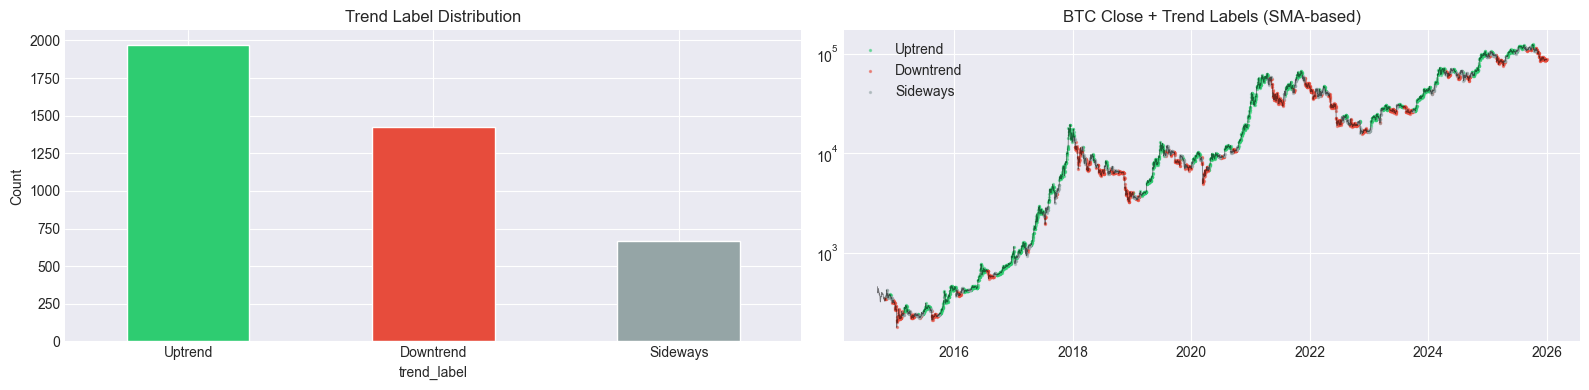

In [3]:
trend_labels = generate_trend_labels(btc)
trend_dist = report_class_distribution(trend_labels, "Stage 1 Trend Labels")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
trend_dist["count"].plot(kind="bar", ax=axes[0], color=["#2ECC71", "#E74C3C", "#95A5A6"], edgecolor="white")
axes[0].set_title("Trend Label Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

color_map = {"Uptrend": "#2ECC71", "Downtrend": "#E74C3C", "Sideways": "#95A5A6"}
axes[1].plot(btc.index, btc["Close"], color="black", linewidth=0.6, alpha=0.5)
for label_name, color in color_map.items():
    mask = trend_labels == label_name
    dates = trend_labels.index[mask]
    if len(dates) > 0:
        prices = btc.loc[dates, "Close"]
        axes[1].scatter(dates, prices, color=color, s=2, alpha=0.5, label=label_name)
axes[1].set_title("BTC Close + Trend Labels (SMA-based)")
axes[1].set_yscale("log")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "trend_labels.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Stage 2 — Macro Regime via GMM Soft Posterior

**MVP yaklaşımı (2026-05-07 kararı):** Stage 2 için ayrı supervised classifier YOK. GMM cluster posterior'ı doğrudan Stage 3'e feature olarak girer.

In [4]:
stage2_feature_names = [
    "macro_VIX",
    "macro_VIX_zscore_50",
    "macro_Yield_Curve_10Y_2Y",
    "macro_Credit_Spread_log",
    "macro_Gold_Silver_Ratio",
    "macro_SP500_VIX_ratio",
    "macro_DXY_zscore_50",
    "macro_SP500_roc_20",
]

available = [c for c in stage2_feature_names if c in macro_feats.columns]
missing = [c for c in stage2_feature_names if c not in macro_feats.columns]
if missing:
    print(f"WARN missing columns: {missing}")
print(f"Stage 2 features ({len(available)}): {available}")

X_stage2 = macro_feats[available].dropna()
print(f"Stage 2 input shape after dropna: {X_stage2.shape}")
print(f"Date range: {X_stage2.index.min().date()} → {X_stage2.index.max().date()}")

Stage 2 features (8): ['macro_VIX', 'macro_VIX_zscore_50', 'macro_Yield_Curve_10Y_2Y', 'macro_Credit_Spread_log', 'macro_Gold_Silver_Ratio', 'macro_SP500_VIX_ratio', 'macro_DXY_zscore_50', 'macro_SP500_roc_20']
Stage 2 input shape after dropna: (4062, 8)
Date range: 2014-11-05 → 2025-12-30


In [5]:
# Train-test split (chronological)
X_stage2_train, X_stage2_test = chronological_train_test_split(X_stage2, test_size=TEST_SIZE)
print(f"Train: {X_stage2_train.shape}  ({X_stage2_train.index.min().date()} → {X_stage2_train.index.max().date()})")
print(f"Test : {X_stage2_test.shape}   ({X_stage2_test.index.min().date()} → {X_stage2_test.index.max().date()})")

Train: (3452, 8)  (2014-11-05 → 2024-04-24)
Test : (610, 8)   (2024-04-25 → 2025-12-30)


### k validation — elbow + silhouette + BIC

   k  kmeans_inertia  kmeans_silhouette    gmm_bic  gmm_silhouette
0  2       21989.048              0.192  57712.745           0.159
1  3       17824.716              0.222  53550.153           0.198
2  4       15585.290              0.226  48068.928           0.137
3  5       14154.148              0.193  45448.269           0.099
4  6       12904.824              0.196  43432.546           0.116


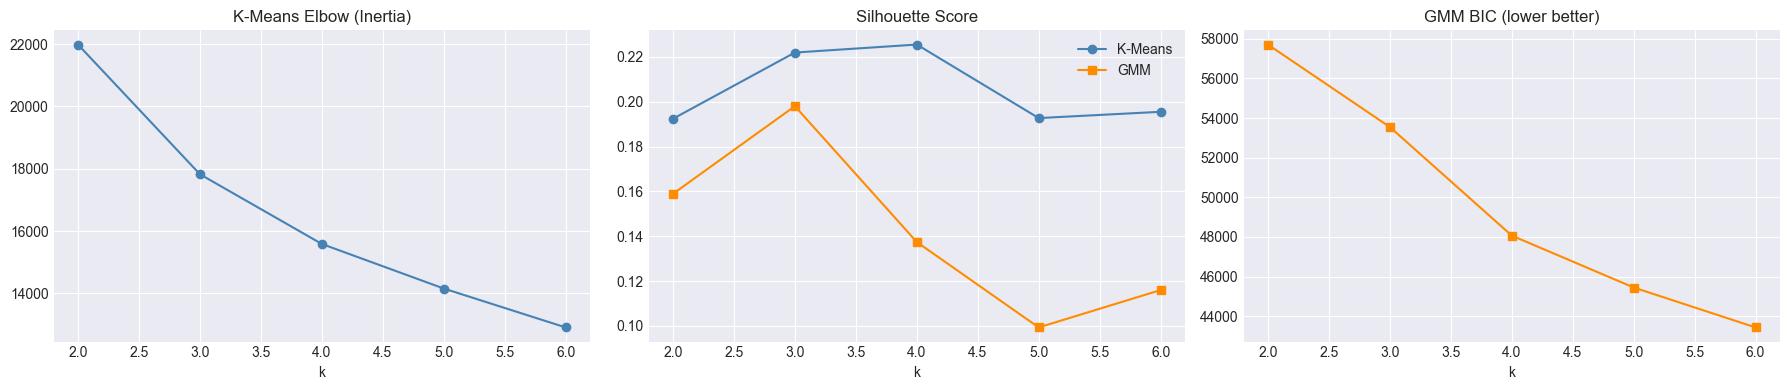


→ MVP'de k=3 kullanılıyor (Risk-On / Neutral / Risk-Off semantik mantık).


In [6]:
scaler_eval = StandardScaler()
X_train_scaled = scaler_eval.fit_transform(X_stage2_train)

k_results = []
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X_train_scaled)
    km_sil = silhouette_score(X_train_scaled, km_labels)

    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE)
    gmm_labels = gmm.fit_predict(X_train_scaled)
    gmm_sil = silhouette_score(X_train_scaled, gmm_labels)

    k_results.append({
        "k": k,
        "kmeans_inertia": km.inertia_,
        "kmeans_silhouette": km_sil,
        "gmm_bic": gmm.bic(X_train_scaled),
        "gmm_silhouette": gmm_sil,
    })

k_df = pd.DataFrame(k_results)
print(k_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(k_df["k"], k_df["kmeans_inertia"], "o-", color="steelblue")
axes[0].set_title("K-Means Elbow (Inertia)"); axes[0].set_xlabel("k")
axes[1].plot(k_df["k"], k_df["kmeans_silhouette"], "o-", label="K-Means", color="steelblue")
axes[1].plot(k_df["k"], k_df["gmm_silhouette"], "s-", label="GMM", color="darkorange")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].legend()
axes[2].plot(k_df["k"], k_df["gmm_bic"], "s-", color="darkorange")
axes[2].set_title("GMM BIC (lower better)"); axes[2].set_xlabel("k")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "k_validation.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n→ MVP'de k=3 kullanılıyor (Risk-On / Neutral / Risk-Off semantik mantık).")

### OOF GMM soft posterior — train kısmı için

Her chronological fold içi: önceki veriyle fit + bu fold'da posterior. İlk fold (no train data) düşürülür.

In [7]:
# OOF posterior on train
oof_train_posterior, full_train_gmm, full_train_scaler = compute_oof_regime_posterior(
    X_stage2_train,
    method="gmm",
    n_clusters=3,
    n_folds=5,
    random_state=RANDOM_STATE,
)
print(f"OOF train posterior shape: {oof_train_posterior.shape}")
print(oof_train_posterior.head())

# Predict test posterior using model fit on full train
test_posterior = predict_regime_posterior(
    X_stage2_test, full_train_gmm, full_train_scaler, method="gmm", n_clusters=3,
)
print(f"\nTest posterior shape: {test_posterior.shape}")

# Concatenate train OOF + test predicted
all_posterior = pd.concat([oof_train_posterior, test_posterior]).sort_index()
print(f"\nTotal posterior coverage: {all_posterior.shape}")

2026-05-07 19:23:21 | src.labels.regime_labels | INFO |   OOF fold 0: skipped (no train data)


2026-05-07 19:23:21 | src.labels.regime_labels | INFO |   OOF fold 1: train=690, val=690, method=gmm


2026-05-07 19:23:21 | src.labels.regime_labels | INFO |   OOF fold 2: train=1380, val=690, method=gmm


2026-05-07 19:23:21 | src.labels.regime_labels | INFO |   OOF fold 3: train=2070, val=690, method=gmm


2026-05-07 19:23:21 | src.labels.regime_labels | INFO |   OOF fold 4: train=2760, val=692, method=gmm


2026-05-07 19:23:21 | src.labels.regime_labels | INFO | OOF regime posterior (gmm): 2762/3452 valid rows, first fold dropped (690 rows)


OOF train posterior shape: (2762, 3)
            regime_prob_0  regime_prob_1  regime_prob_2
Date                                                   
2016-09-26   1.252332e-39            1.0   1.101760e-38
2016-09-27   1.026625e-14            1.0   4.741512e-14
2016-09-28   3.409828e-28            1.0   1.491781e-26
2016-09-29   1.296505e-42            1.0   2.941273e-37
2016-09-30   1.074883e-17            1.0   1.181882e-16

Test posterior shape: (610, 3)

Total posterior coverage: (3372, 3)


### semantik regime atama (VIX-based) + PCA görselleştirme

In [8]:
hard_train = oof_train_posterior.idxmax(axis=1).str.replace("regime_prob_", "").astype(int)
vix_per_cluster = X_stage2_train.loc[hard_train.index].assign(cluster=hard_train).groupby("cluster")["macro_VIX"].mean()
print("Mean VIX per cluster (train OOF):")
print(vix_per_cluster.sort_values())

sorted_clusters = vix_per_cluster.sort_values().index.tolist()
semantic_map = {sorted_clusters[0]: "Risk-On", sorted_clusters[1]: "Neutral", sorted_clusters[2]: "Risk-Off"}
print(f"\nSemantic mapping: {semantic_map}")

all_hard = all_posterior.idxmax(axis=1).str.replace("regime_prob_", "").astype(int)
regime_labels_semantic = all_hard.map(semantic_map).rename("regime_label")
regime_dist = report_class_distribution(regime_labels_semantic, "Stage 2 Regime Labels (semantic)")

Mean VIX per cluster (train OOF):
cluster
0    17.216096
1    17.231762
2    23.347719
Name: macro_VIX, dtype: float64

Semantic mapping: {0: 'Risk-On', 1: 'Neutral', 2: 'Risk-Off'}

--- Stage 2 Regime Labels (semantic) Class Distribution ---
              count  percentage
regime_label                   
Neutral        1827       54.18
Risk-Off       1012       30.01
Risk-On         533       15.81
Total: 3372


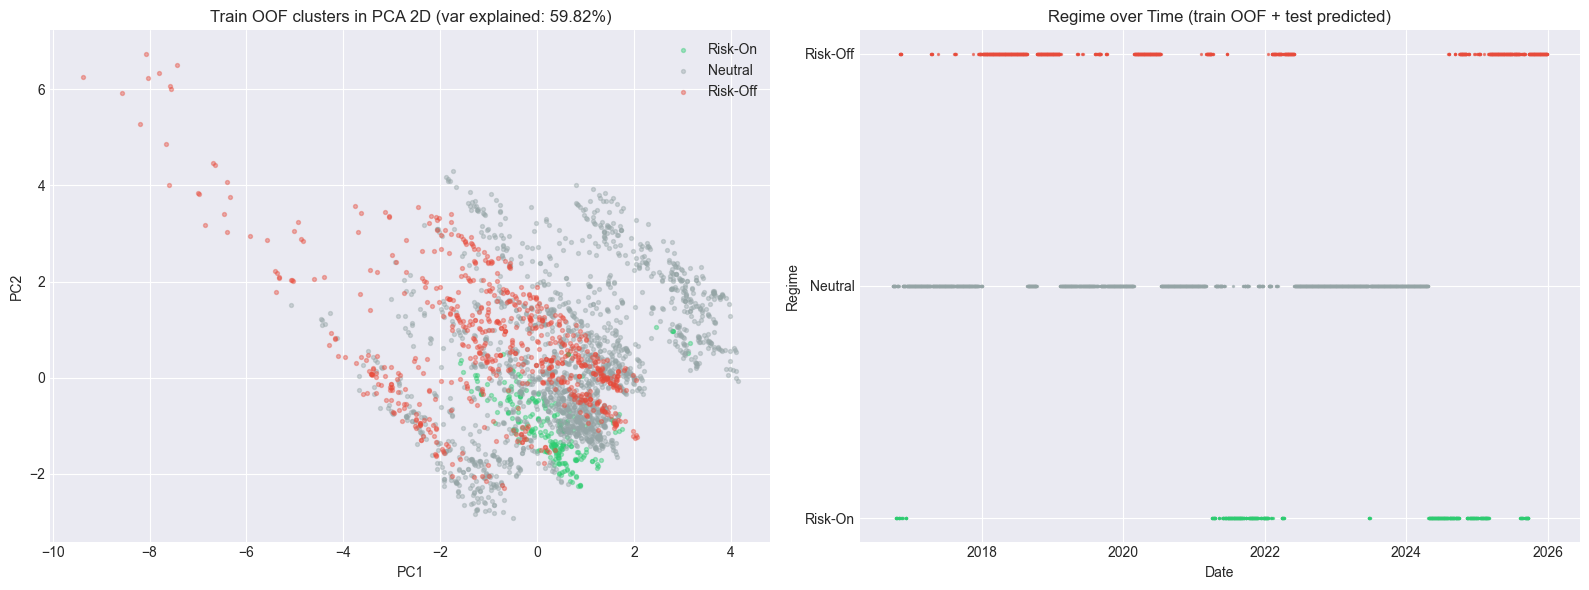

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_for_pca = full_train_scaler.transform(X_stage2_train)
X_pca_train = pca.fit_transform(X_train_for_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
regime_color = {"Risk-On": "#2ECC71", "Neutral": "#95A5A6", "Risk-Off": "#E74C3C"}

hard_train_aligned = hard_train.map(semantic_map)
for regime, color in regime_color.items():
    mask = hard_train_aligned == regime
    if mask.sum() == 0:
        continue
    train_idx_in_oof = X_stage2_train.index.isin(hard_train_aligned.index[mask])
    axes[0].scatter(X_pca_train[train_idx_in_oof, 0], X_pca_train[train_idx_in_oof, 1],
                    c=color, label=regime, alpha=0.4, s=8)
axes[0].set_title(f"Train OOF clusters in PCA 2D (var explained: {pca.explained_variance_ratio_.sum():.2%})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

for regime, color in regime_color.items():
    mask = regime_labels_semantic == regime
    if mask.sum() == 0:
        continue
    dates = regime_labels_semantic.index[mask]
    axes[1].scatter(dates, [regime] * len(dates), c=color, s=2, alpha=0.6)
axes[1].set_title("Regime over Time (train OOF + test predicted)")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Regime")
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "regime_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Stage 3 — Signal Labels (forward return)

MVP'de **Yöntem 1 (sabit ±1%)** primary olarak kullanılır + class_weight='balanced'. Yöntem 2 (volatility-adjusted) raporda alternatif olarak gösterilir.

2026-05-07 19:23:21 | src.labels.signal_labels | INFO | Fixed-threshold signal labels: forward=5d, threshold=±1.00%
  Distribution: {'Buy': 1908, 'Sell': 1521, 'Hold': 677}


2026-05-07 19:23:21 | src.labels.signal_labels | INFO | Adaptive-threshold signal labels: forward=5d, c=0.5, window=20
  Distribution: {'Buy': 1785, 'Sell': 1418, 'Hold': 883}



--- Signal Labels (FIXED ±1%) Class Distribution ---
              count  percentage
signal_label                   
Buy            1908       46.47
Sell           1521       37.04
Hold            677       16.49
Total: 4106

--- Signal Labels (ADAPTIVE 0.5×std) Class Distribution ---
              count  percentage
signal_label                   
Buy            1785       43.69
Sell           1418       34.70
Hold            883       21.61
Total: 4086


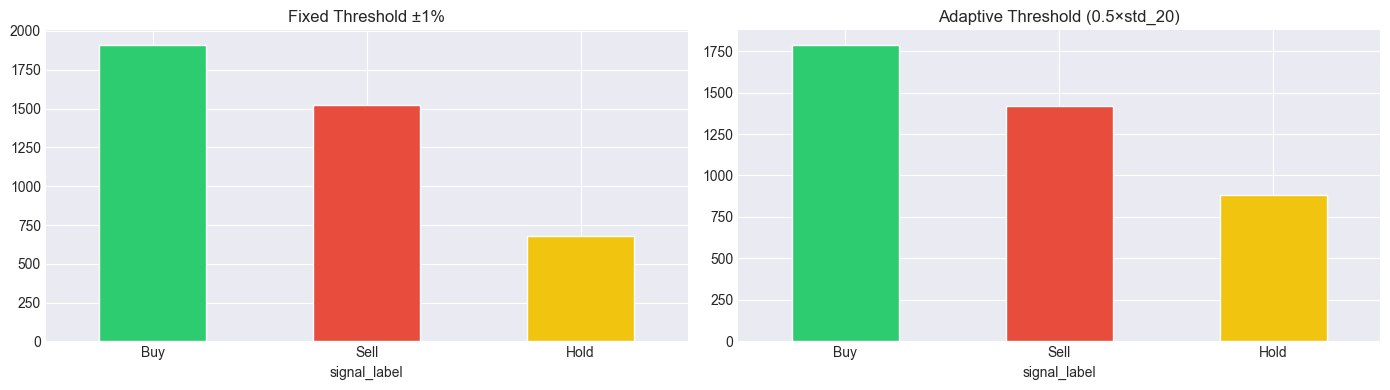

In [10]:
signal_fixed = generate_signal_labels_fixed(btc["Close"])
signal_adaptive = generate_signal_labels_adaptive(btc["Close"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fixed_dist = report_class_distribution(signal_fixed, "Signal Labels (FIXED ±1%)")
fixed_dist["count"].plot(kind="bar", ax=axes[0], color=["#2ECC71", "#E74C3C", "#F1C40F"], edgecolor="white")
axes[0].set_title("Fixed Threshold ±1%")
axes[0].tick_params(axis='x', rotation=0)

adaptive_dist = report_class_distribution(signal_adaptive, "Signal Labels (ADAPTIVE 0.5×std)")
adaptive_dist["count"].plot(kind="bar", ax=axes[1], color=["#2ECC71", "#E74C3C", "#F1C40F"], edgecolor="white")
axes[1].set_title("Adaptive Threshold (0.5×std_20)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "signal_labels.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Leakage Verification (CRITICAL)

In [11]:
stage1_features = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_features_stage1.csv", index_col=0, parse_dates=True)
stage3_features = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_features_stage3.csv", index_col=0, parse_dates=True)

verify_no_leakage(stage1_features.dropna(), btc["Close"].loc[stage1_features.dropna().index], forward_days=5)
print("  → Stage 1 features: leakage check PASSED")

verify_no_leakage(stage3_features.dropna(), btc["Close"].loc[stage3_features.dropna().index], forward_days=5)
print("  → Stage 3 features: leakage check PASSED")

verify_no_leakage(X_stage2.dropna(), btc["Close"].loc[X_stage2.dropna().index], forward_days=5)
print("  → Stage 2 features: leakage check PASSED")

2026-05-07 19:23:21 | src.labels.signal_labels | INFO | Leakage check passed: 16 features verified


2026-05-07 19:23:21 | src.labels.signal_labels | INFO | Leakage check passed: 18 features verified


2026-05-07 19:23:21 | src.labels.signal_labels | INFO | Leakage check passed: 8 features verified


  → Stage 1 features: leakage check PASSED
  → Stage 3 features: leakage check PASSED
  → Stage 2 features: leakage check PASSED


## 5. Save labels + cluster artifact

In [12]:
labels_dir = PROJECT_ROOT / "data" / "labels"
labels_dir.mkdir(parents=True, exist_ok=True)
models_dir = PROJECT_ROOT / "app" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

save_csv(trend_labels.to_frame(), labels_dir / "btc_trend_labels.csv")
save_csv(signal_fixed.to_frame(), labels_dir / "btc_signal_labels_fixed.csv")
save_csv(signal_adaptive.to_frame(), labels_dir / "btc_signal_labels_adaptive.csv")
save_csv(all_posterior, labels_dir / "btc_oof_regime_posterior.csv")
save_csv(regime_labels_semantic.to_frame(), labels_dir / "btc_regime_labels_semantic.csv")

stage2_artifact = {
    "model": full_train_gmm,
    "scaler": full_train_scaler,
    "method": "gmm",
    "n_clusters": 3,
    "feature_names": available,
    "semantic_map": semantic_map,
    "train_period": (X_stage2_train.index.min().isoformat(), X_stage2_train.index.max().isoformat()),
}
joblib.dump(stage2_artifact, models_dir / "stage2_cluster_artifact.joblib")

print("Saved files:")
for p in sorted(labels_dir.glob("*.csv")):
    print(f"  {p.name:40s} {p.stat().st_size/1024:8.1f} KB")
print(f"  app/models/stage2_cluster_artifact.joblib  {(models_dir / 'stage2_cluster_artifact.joblib').stat().st_size/1024:.1f} KB")

Saved files:
  btc_oof_regime_posterior.csv                206.8 KB
  btc_regime_labels_semantic.csv               63.6 KB
  btc_signal_labels_adaptive.csv               62.1 KB
  btc_signal_labels_fixed.csv                  62.3 KB
  btc_trend_labels.csv                         78.8 KB
  app/models/stage2_cluster_artifact.joblib  7.1 KB


## Checkpoint #2 — Kullanıcı incelemesi

### beklenen sonuçlar
- Stage 1 trend dist: Uptrend ~ %35-45, Downtrend ~ %25-35, Sideways ~ %20-30
- Stage 2 cluster k=3: Silhouette 0.20-0.40 arası
- Stage 3 signal: Hold ~ %30-50, Buy + Sell ~ %50-70 birlikte (class_weight='balanced' telafi edecek)
- Leakage check: PASSED (3 stage)
- Risk-Off cluster ortalama VIX ~25+, Risk-On ~15-

### sonraki adım
Onaylarsan **FAZ 4** (notebooks 05 + 07): Stage 1 ve Stage 3 LDA + MLP eğitimi, Optuna walk-forward.